In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy.stats import gaussian_kde, norm

sys.path.insert(0, str(Path('..').resolve()))
from evaluate import *

Path('../figures').mkdir(parents=True, exist_ok=True)


In [2]:
# Plot configs
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

C_GEN = 'tab:cyan'
C_REAL = 'tab:blue'
C_NORMAL = 'tab:red'

print(f"Plot config defined.")


Plot config defined.


In [3]:
"""
Load data from generated and real returns.
"""

# Generated returns
with open('../data/generated/generated_returns5000.json') as f:
    gen_data = json.load(f)
gen_np = np.array(gen_data['samples'], dtype=np.float64)   # (200, 64)
conditions = gen_data['conditions']

# Real returns 
PREP_DIR = Path('../data/preprocessed')
real_windows = []
for fpath in sorted(PREP_DIR.glob('prep_data_*.json')):
    with open(fpath) as f:
        records = json.load(f)
        for rec in records:
            real_windows.append(rec['returns'])
real_np = np.array(real_windows, dtype=np.float64)   # (N_real, 64)


print(f"Generated: {gen_np.shape[0]} sequences x {gen_np.shape[1]} steps")
print("Conditions:", {k: v for k, v in conditions.items() if k != 'guidance_scale'})
print()
print(f"Real: {real_np.shape[0]} sequences x {real_np.shape[1]} steps")


Generated: 5000 sequences x 64 steps
Conditions: {'trend': 0.0, 'realized_vol': 50.0, 'interest_rate': 5.0, 'volatility_index': 20.0}

Real: 7079 sequences x 64 steps


In [4]:
"""
1.1 - Fisher's excess kurtosis.
"""

# Flat pools used for KDE and percentile analysis
flat_gen  = gen_np.ravel()    # (N_gen*T,)
flat_real = real_np.ravel()   # (N_real*T,)

# Fisher's excess kurtosis
kurt_gen  = fisher_kurtosis(gen_np)    # (N_gen,)
kurt_real = fisher_kurtosis(real_np)   # (N_real,)

for label, k in [('Generated', kurt_gen), ('Real', kurt_real), ('Normal ref', np.array([0.0]))]:
    print(f"{label:12s}  {k.mean():>8.3f}  {k.std():>8.3f}  {np.median(k):>8.3f}")

Generated        0.868     1.718     0.399
Real             2.478     4.738     0.983
Normal ref       0.000     0.000     0.000


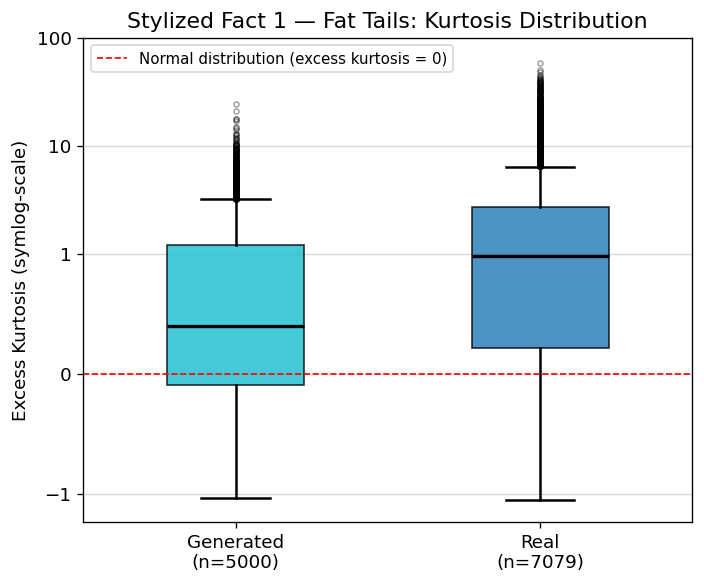

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))

# Boxplot
bp = ax.boxplot(
    [kurt_gen, kurt_real],
    tick_labels=[f'Generated\n(n={gen_np.shape[0]})', f'Real\n(n={real_np.shape[0]})'],
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.35, linestyle='none'),
)

# Set colors, transparency
bp['boxes'][0].set_facecolor(C_GEN)
bp['boxes'][0].set_alpha(0.8)
bp['boxes'][1].set_facecolor(C_REAL)
bp['boxes'][1].set_alpha(0.8)

# Axis settings
ax.set_title('Stylized Fact 1 — Fat Tails: Kurtosis Distribution')  # Title
ax.set_ylabel('Excess Kurtosis (symlog-scale)')
ax.set_yscale('symlog', linthresh=1)
ax.set_ylim(ax.get_ylim()[0], 100)
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.get_major_formatter().set_scientific(False)
ax.axhline(0, color='red', linestyle='--', linewidth=1.0, label='Normal distribution (excess kurtosis = 0)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('../figures/kurtosis_boxplot.png', bbox_inches='tight')
plt.show()

In [6]:
"""
1.2 - 5% and 95% percentiles.
"""

# Row data
rows = [
    ('Generated', np.percentile(flat_gen, [5, 95])),
    ('Real', np.percentile(flat_real, [5, 95])),
    ('Normal (ref)', norm.ppf([0.05, 0.95])),
]

# Chart
print(f"{'Distribution':16s}  {'5th pct':>10s}  {'95th pct':>10s}  {'Range':>10s}")
print("-" * 52)
for label, (p5, p95) in rows:
    print(f"{label:16s}  {p5:>10.4f}  {p95:>10.4f}  {p95 - p5:>10.4f}")

Distribution         5th pct    95th pct       Range
----------------------------------------------------
Generated            -1.5928      1.5833      3.1762
Real                 -1.5726      1.5899      3.1625
Normal (ref)         -1.6449      1.6449      3.2897


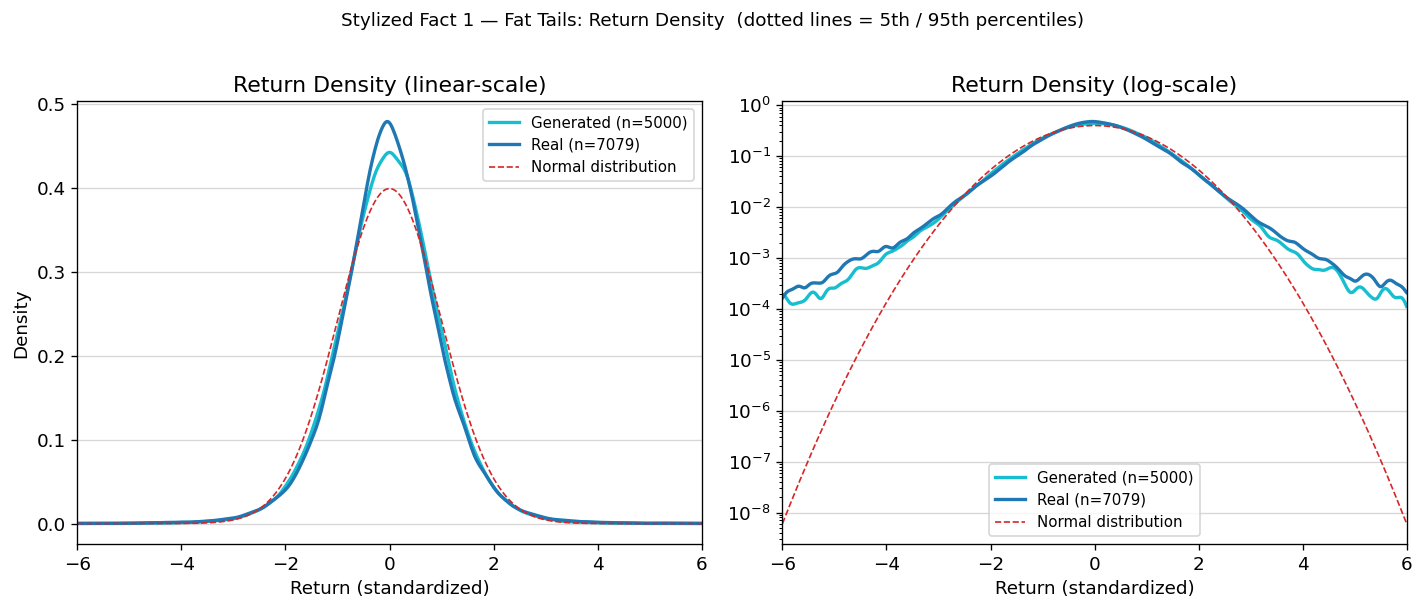

In [7]:
"""
1.3 - KDE overlay.
"""

# KDE curves
x_grid = np.linspace(-6, 6, 500)
kde_gen = gaussian_kde(flat_gen, bw_method='scott')(x_grid)
kde_real = gaussian_kde(flat_real, bw_method='scott')(x_grid)
pdf_norm = norm.pdf(x_grid)

# Percentiles
p5_gen, p95_gen = np.percentile(flat_gen, [5, 95])
p5_real, p95_real = np.percentile(flat_real, [5, 95])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, yscale in zip(axes, ['linear', 'log']):
    ax.plot(x_grid, kde_gen, color=C_GEN, lw=2, label=f'Generated (n={gen_np.shape[0]})')
    ax.plot(x_grid, kde_real, color=C_REAL, lw=2, label=f'Real (n={real_np.shape[0]})')
    ax.plot(
        x_grid,
        pdf_norm,
        color=C_NORMAL,
        linestyle='--',
        linewidth=1.0,
        label='Normal distribution',
    )

    ax.set_xlim(-6, 6)
    ax.set_xlabel('Return (standardized)')
    ax.set_yscale(yscale)
    ax.set_title(f'Return Density ({yscale}-scale)')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.5)

axes[0].set_ylabel('Density')
fig.suptitle('Stylized Fact 1 — Fat Tails: Return Density  (dotted lines = 5th / 95th percentiles)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('../figures/kde_overlay.png', bbox_inches='tight')
plt.show()


In [8]:
"""
2.1 - ACF table.
"""

# Tau lags
TABLE_LAGS = [1, 5, 10, 20, 30]

# ACF values
acf_gen_tbl  = acf_squared(gen_np,  TABLE_LAGS)
acf_real_tbl = acf_squared(real_np, TABLE_LAGS)

# Chart
header = f"{'':12s}" + "".join(f"  lag={l:>2d}" for l in TABLE_LAGS)
print(header)
print("-" * len(header))
for label, vals in [('Generated', acf_gen_tbl), ('Real', acf_real_tbl)]:
    row = f"{label:12s}" + "".join(f"  {v:>7.4f}" for v in vals)
    print(row)


              lag= 1  lag= 5  lag=10  lag=20  lag=30
----------------------------------------------------
Generated      0.0704   0.0061  -0.0122  -0.0137  -0.0134
Real           0.0303   0.0028  -0.0048  -0.0161  -0.0123


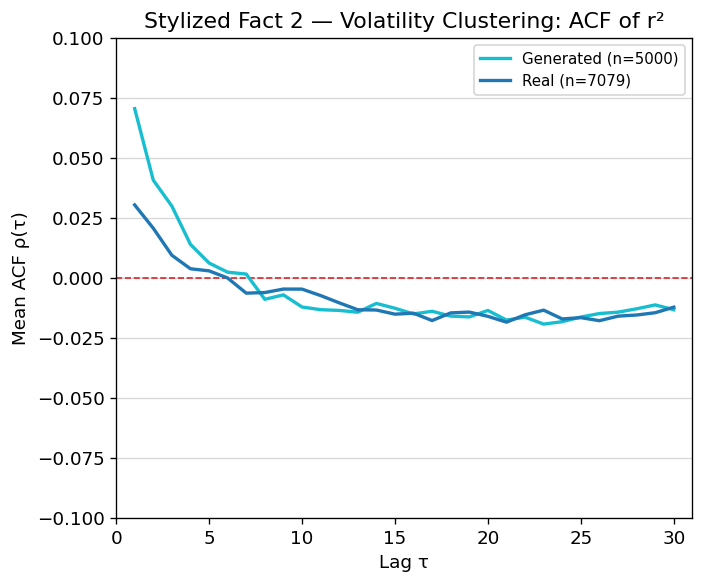

In [9]:
"""
2.2 - ACF plot.
"""
# Tau lags
ALL_LAGS = np.arange(1, 31)

# ACF values
acf_gen_full  = acf_squared(gen_np,  ALL_LAGS)
acf_real_full = acf_squared(real_np, ALL_LAGS)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.axhline(0, color=C_NORMAL, linestyle='--', linewidth=1.0)
ax.plot(ALL_LAGS, acf_gen_full, color=C_GEN, lw=2, label=f'Generated (n={gen_np.shape[0]})')
ax.plot(ALL_LAGS, acf_real_full, color=C_REAL, lw=2, label=f'Real (n={real_np.shape[0]})')
ax.set_xlabel('Lag τ')
ax.set_ylabel('Mean ACF ρ(τ)')
ax.set_title('Stylized Fact 2 — Volatility Clustering: ACF of r²')
ax.set_xlim(0, 31)
ax.set_ylim(-0.1, 0.1)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('../figures/acf_curve.png', bbox_inches='tight')
plt.show()
